# EDA - Client Profile (Member 1)

**Features:** `age`, `job`, `marital`, `education`  |  **Target:** `y` (term deposit subscription)

`duration` is dropped immediately because it is only known after the call ends (data leakage). All observations here are used to decide preprocessing for these features.

## 0. Setup

In [ ]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

# make `src` importable when the notebook runs from /notebooks
sys.path.append(str(Path.cwd().parent))
from src.config import RAW_DATA, TARGET, LEAKAGE_COLUMNS, ROOT

FIG_DIR = ROOT / "results" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")


def save_fig(name):
    """Save the current figure into results/figures with the eda_client_ prefix."""
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"eda_client_{name}.png", dpi=150, bbox_inches="tight")

## 1. Load data and basic structure

In [ ]:
# The UCI file uses ';' as separator - detect it from the first line
with open(RAW_DATA, encoding="utf-8") as f:
    sep = ";" if ";" in f.readline() else ","

df = pd.read_csv(RAW_DATA, sep=sep)
df = df.drop(columns=LEAKAGE_COLUMNS, errors="ignore")   # leakage: not available before a call
df["y_bin"] = (df[TARGET] == "yes").astype(int)          # 1 = subscribed

print("Shape:", df.shape)
print("Duplicated rows:", df.duplicated().sum())
print("\nTarget distribution:")
print(pd.concat([df[TARGET].value_counts().rename("count"),
                 df[TARGET].value_counts(normalize=True).mul(100).round(2).rename("percent")], axis=1))
df[["age", "job", "marital", "education"]].info()

Shape: (41188, 21)
Duplicated rows: 1784

Target distribution:
     count  percent
y                  
no   36548   88.730
yes   4640   11.270
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        41188 non-null  int64 
 1   job        41188 non-null  object
 2   marital    41188 non-null  object
 3   education  41188 non-null  object
dtypes: int64(1), object(3)
memory usage: 1.3+ MB


### Insight -> decision

- Finding: 41,188 raw rows, 88.73% no / 11.27% yes. Strong imbalance means accuracy is not usable as the main metric — predicting "no" for everyone already scores 88.7% while finding zero subscribers.
- Decision: use PR-AUC, recall, precision and F1 instead of accuracy for every model.
- Reason: accuracy would hide model failure on the class we actually care about.

## 2. Age

In [ ]:
print(df["age"].describe())

# IQR rule for outliers
q1, q3 = df["age"].quantile([0.25, 0.75])
iqr = q3 - q1
low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
n_out = ((df["age"] < low) | (df["age"] > high)).sum()
print(f"\nIQR bounds: {low:.1f} to {high:.1f}  ->  {n_out} outliers ({n_out / len(df):.2%})")

count   41,188.000
mean        40.024
std         10.421
min         17.000
25%         32.000
50%         38.000
75%         47.000
max         98.000
Name: age, dtype: float64

IQR bounds: 9.5 to 69.5  ->  469 outliers (1.14%)


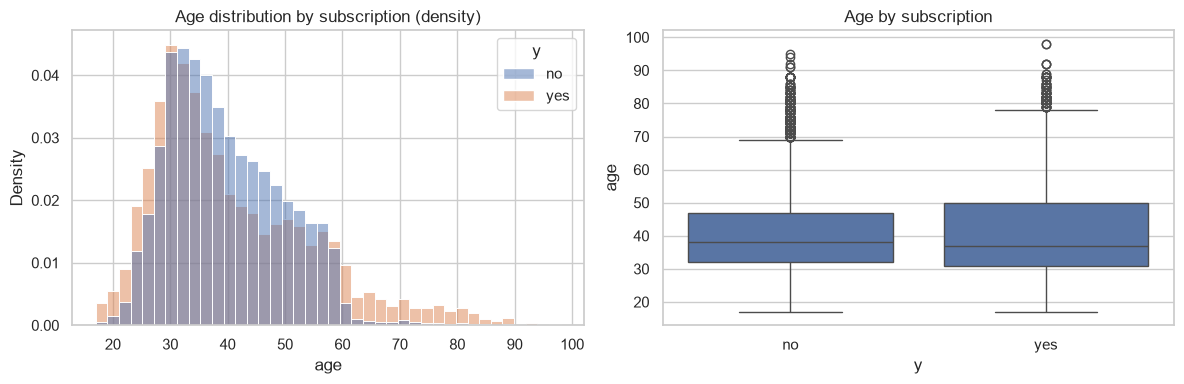

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data=df, x="age", hue=TARGET, bins=40, stat="density", common_norm=False, ax=ax[0])
ax[0].set_title("Age distribution by subscription (density)")
sns.boxplot(data=df, x=TARGET, y="age", ax=ax[1])
ax[1].set_title("Age by subscription")
save_fig("age_distribution")
plt.show()

### Insight -> decision

- Finding: age is right-skewed (mean 40.0, median 38, range 17-98). Using the IQR rule, only 469 rows (1.14%) are flagged as outliers, and the boxplots show similar age spread between subscribers and non-subscribers.
- Decision: don't drop the flagged outliers — they are plausible real ages (elderly clients), not data errors.
- Reason: removing them would lose exactly the older-client segment we later find converts best.

### Yes-rate by age band

           count  yes_rate_%
age_group                   
<25         1068      23.970
25-34      13686      12.173
35-44      13500       8.652
45-54       8704       8.651
55-64       3567      13.569
65+          663      47.210


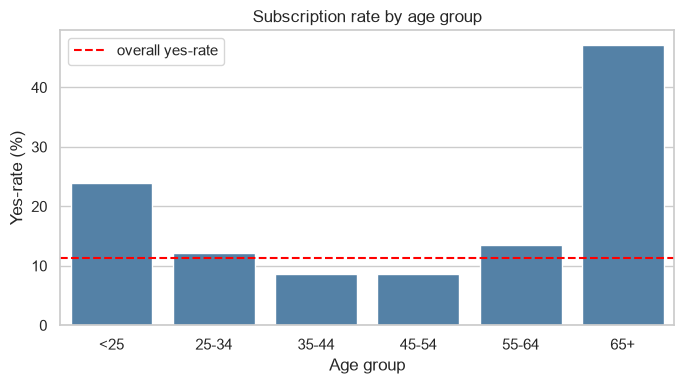

In [ ]:
bins = [16, 24, 34, 44, 54, 64, 100]
labels = ["<25", "25-34", "35-44", "45-54", "55-64", "65+"]
df["age_group"] = pd.cut(df["age"], bins=bins, labels=labels)

age_tbl = df.groupby("age_group", observed=True)["y_bin"].agg(count="count", yes_rate="mean")
age_tbl["yes_rate_%"] = age_tbl["yes_rate"] * 100
print(age_tbl[["count", "yes_rate_%"]])

plt.figure(figsize=(7, 4))
sns.barplot(x=age_tbl.index.astype(str), y=age_tbl["yes_rate_%"], color="steelblue")
plt.axhline(df["y_bin"].mean() * 100, color="red", ls="--", label="overall yes-rate")
plt.ylabel("Yes-rate (%)"); plt.xlabel("Age group"); plt.title("Subscription rate by age group")
plt.legend()
save_fig("age_group_yes_rate")
plt.show()

### Insight -> decision

- Finding: yes-rate is U-shaped by age, not linear — 65+ converts best (47.2%), <25 is also high (24.0%), while 35-54 is lowest (~8.65%).
- Decision: bin age into groups (age_group) rather than using raw age as a linear term.
- Reason: a linear model like Logistic Regression can't see a U-shaped pattern from raw age alone; binning exposes it. Tree models could find this without binning, so this decision matters most for the linear baseline.

## 3. Job, marital status and education

In [ ]:
def rate_table(col):
    t = df.groupby(col)["y_bin"].agg(count="count", yes_rate="mean")
    t["yes_rate_%"] = t["yes_rate"] * 100
    t["share_of_rows_%"] = t["count"] / len(df) * 100
    return t.sort_values("yes_rate_%", ascending=False)[["count", "share_of_rows_%", "yes_rate_%"]]


for col in ["job", "marital", "education"]:
    print(f"\n=== {col} ===")
    print(rate_table(col))


=== job ===
               count  share_of_rows_%  yes_rate_%
job                                              
student          875            2.124      31.429
retired         1720            4.176      25.233
unemployed      1014            2.462      14.201
admin.         10422           25.303      12.973
management      2924            7.099      11.218
unknown          330            0.801      11.212
technician      6743           16.371      10.826
self-employed   1421            3.450      10.486
housemaid       1060            2.574      10.000
entrepreneur    1456            3.535       8.516
services        3969            9.636       8.138
blue-collar     9254           22.468       6.894

=== marital ===
          count  share_of_rows_%  yes_rate_%
marital                                     
unknown      80            0.194      15.000
single    11568           28.086      14.004
divorced   4612           11.197      10.321
married   24928           60.522      10.157


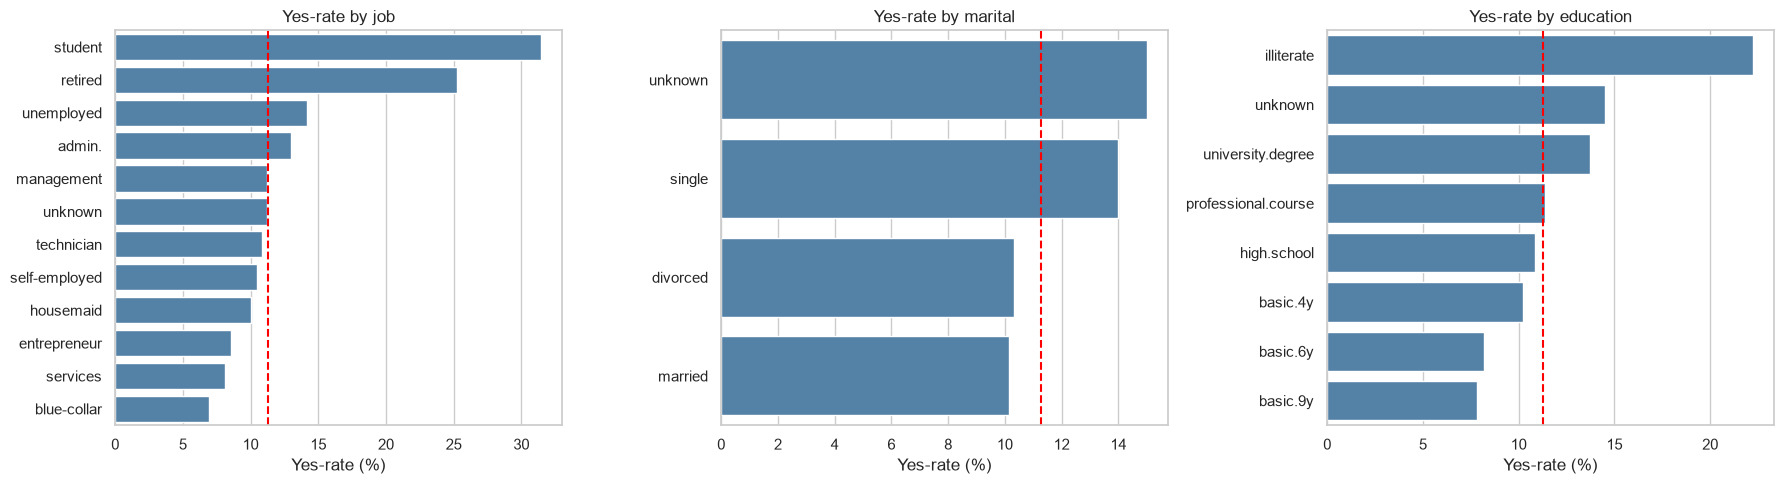

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, ["job", "marital", "education"]):
    t = rate_table(col)
    sns.barplot(x=t["yes_rate_%"], y=t.index, color="steelblue", ax=ax)
    ax.axvline(df["y_bin"].mean() * 100, color="red", ls="--")
    ax.set_title(f"Yes-rate by {col}"); ax.set_xlabel("Yes-rate (%)"); ax.set_ylabel("")
save_fig("categorical_yes_rate")
plt.show()

### Insight -> decision

- Finding: student (31.4%) and retired (25.2%) convert far above average; blue-collar (6.9%) and services (8.1%) convert worst. job separates classes much more than marital.
- Decision: keep job as a strong predictor; don't expect much signal from marital alone.
- Reason: based directly on the yes-rate table and bar chart above.  

## 4. Audit of 'unknown' values

In [ ]:
rows = []
for col in ["job", "marital", "education"]:
    is_unk = df[col] == "unknown"
    rows.append({
        "feature": col,
        "unknown_count": int(is_unk.sum()),
        "unknown_%_of_rows": is_unk.mean() * 100,
        "yes_rate_unknown_%": df.loc[is_unk, "y_bin"].mean() * 100 if is_unk.any() else np.nan,
        "yes_rate_known_%": df.loc[~is_unk, "y_bin"].mean() * 100,
    })
unknown_audit = pd.DataFrame(rows).set_index("feature")
print(unknown_audit)

           unknown_count  unknown_%_of_rows  yes_rate_unknown_%  \
feature                                                           
job                  330              0.801              11.212   
marital               80              0.194              15.000   
education           1731              4.203              14.500   

           yes_rate_known_%  
feature                      
job                  11.266  
marital              11.258  
education            11.124  


### Insight -> decision (how to treat 'unknown')

- Finding: job's unknown yes-rate (11.21%) is nearly identical to known (11.27%) — no signal. marital's unknown differs (15.0%) but only 80 rows, too small to trust. education's unknown yes-rate (14.5%) vs known (11.1%) is a real, consistent gap on a larger sample (1,731 rows).
- Decision: keep "unknown" as its own category in all three columns, rather than imputing it.
- Reason: the mini-experiment in notebook 06 shows mode imputation gives no real PR-AUC improvement (0.2025 vs 0.2027 — smaller than the ±0.025 CV standard deviation), and keeping the category preserves the real signal found in education.

## 5. Association with the target (chi-square and Cramer's V)

In [ ]:
def cramers_v(a, b):
    table = pd.crosstab(a, b)
    chi2, p, dof, _ = chi2_contingency(table)
    v = np.sqrt(chi2 / (table.values.sum() * (min(table.shape) - 1)))
    return chi2, p, dof, v


rows = []
for col in ["job", "marital", "education"]:
    chi2, p, dof, v = cramers_v(df[col], df[TARGET])
    rows.append({"feature": col, "chi2": chi2, "dof": dof, "p_value": p, "cramers_v": v})

# age is numeric: use the age bands for the same test
chi2, p, dof, v = cramers_v(df["age_group"], df[TARGET])
rows.append({"feature": "age (binned)", "chi2": chi2, "dof": dof, "p_value": p, "cramers_v": v})

assoc = pd.DataFrame(rows).set_index("feature").sort_values("cramers_v", ascending=False)
print(assoc)

                  chi2  dof  p_value  cramers_v
feature                                        
age (binned) 1,211.315    5    0.000      0.171
job            961.242   11    0.000      0.153
education      193.106    7    0.000      0.068
marital        122.655    3    0.000      0.055


### Insight -> decision (which client features matter most)

- Finding: age (binned) is the strongest predictor of the four (Cramer's V 0.171), then job (0.153); education (0.068) and marital (0.055) are weak.
- Decision: focus explanations in the report/presentation on age and job.
- Reason: these two carry most of the client-profile signal; marital adds little.

## 6. Summary of decisions for preprocessing

| Feature | Problem found | Decision | Evidence |
|---|---|---|---|
| age | raw age has a U-shaped relationship with target, not linear | bin into age_group | Cramer's V 0.171 (highest); yes-rate 65+: 47.2%, <25: 24.0%, 35-54: ~8.65% |
| job | strong variation in yes-rate by category | keep as key categorical predictor | Cramer's V 0.153; student 31.4%, retired 25.2% vs blue-collar 6.9% |
| marital | weak association with target | keep but expect little signal | Cramer's V 0.055 (lowest) |
| education | moderate association; unknown category shows real signal | keep as predictor, retain 'unknown' as category | Cramer's V 0.068; unknown yes-rate 14.5% vs known 11.1% |
| unknown values | job/marital unknowns show no clear signal; education unknowns do | keep "unknown" as its own category everywhere, don't impute | mode imputation gave no PR-AUC gain (0.2025 vs 0.2027, within CV std) |